<a href="https://colab.research.google.com/github/GitGirlie27/urdu-ocr-codesaviours-si26-Amna/blob/main/SI26_Week2_Amna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# **PREPROCESSING

# *Install Packages*

In [1]:
!pip install opencv-python-headless pillow

# *Install Libraries*

In [9]:
import cv2
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt
print('Libraries loaded successfully!')

Libraries loaded successfully!


# *Import ZIP File*

In [14]:
import zipfile

zip_path = "/content/Urdu OCR Dataset Folder.zip"
extract_path = "/content/Urdu_OCR_Dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


# *Image Preprocessing Techniques*

In [28]:
def preprocess_image(image_path, save_path):
    # Load image
    img = cv2.imread(image_path)

    if img is None:
        print(f"Could not load: {image_path}")
        return

    # Step 1: Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Step 2: Resize to a standard size
    resized = cv2.resize(gray, (512, 128), interpolation=cv2.INTER_AREA)

    # Step 3: Remove noise
    denoised = cv2.fastNlMeansDenoising(resized, None, h=10)

    # Step 4: Binarize the image
    _, binary = cv2.threshold(
        denoised,
        127,
        255,
        cv2.THRESH_BINARY
    )

    # Save processed image
    cv2.imwrite(save_path, binary)

    return binary

# *Save Output Folder*

In [26]:
output_folder = "/content/processed"
os.makedirs(output_folder, exist_ok=True)

# *Processed Data*

In [29]:
# Folder containing the PNG images
input_folder = "/content/Urdu_OCR_Dataset/Urdu OCR Dataset"

# Read all PNG images
image_paths = sorted(glob.glob(os.path.join(input_folder, "*.png")))

print("Total images found:", len(image_paths))

# Process every image
for image_path in image_paths:
    filename = os.path.basename(image_path)
    save_path = os.path.join(output_folder, filename)

    preprocess_image(image_path, save_path)

print("All images have been preprocessed successfully!")

Total images found: 134
All images have been preprocessed successfully!


# *Display Image*

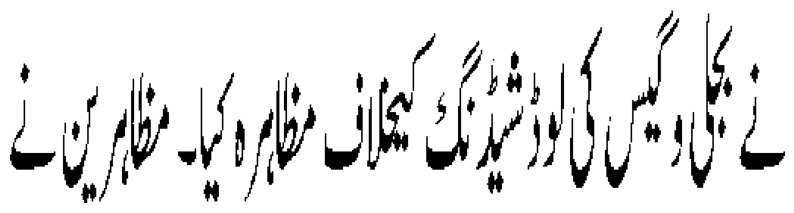

In [24]:
import matplotlib.pyplot as plt

img = cv2.imread("/content/processed/10.png", cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10,4))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()